In [ ]:
import numpy as np
import pandas as pd

def EDO(l, f_T, mu, n):

    # Definamos la posición de los nodos interiores, así como la distancia entre estos
    dx = (l) / (n+1)
    x = np.linspace(dx, l-dx,n)

    # Definamos la matriz del sistema A, que viene de discretizar la EDO;
    # y la matriz M, que representa la discretización de la densidad de masa en cada nodo. 

    A = np.zeros((n,n))
    M = np.zeros((n,n))

    for i in range(n):
        M[i,i] = mu(x[i])

        A[i,i] = (2*f_T) / dx**2

        if i > 0:
            A[i,i-1] = -f_T / dx**2
        if i < n-1:
            A[i,i+1] = -f_T / dx**2


    return A, M

In [4]:
EDO(1,1, lambda x: 1+0.2*x, 3)

(array([[ 32., -16.,   0.],
        [-16.,  32., -16.],
        [  0., -16.,  32.]]),
 array([[1.05, 0.  , 0.  ],
        [0.  , 1.1 , 0.  ],
        [0.  , 0.  , 1.15]]))

In [5]:
def simetric(l, f_t, mu, n):

    A, M = EDO(l, f_t, mu, n)

    D = np.zeros((n,n))

    for i in range(n):

        D[i, i]= 1 / np.sqrt(M[i,i])

    C = D @ A @ D

    return C, D, M

simetric(1, 1, lambda x: 1+0.5*x, 3)

(array([[ 28.44444444, -13.49238468,   0.        ],
        [-13.49238468,  25.6       , -12.20432114],
        [  0.        , -12.20432114,  23.27272727]]),
 array([[0.94280904, 0.        , 0.        ],
        [0.        , 0.89442719, 0.        ],
        [0.        , 0.        , 0.85280287]]),
 array([[1.125, 0.   , 0.   ],
        [0.   , 1.25 , 0.   ],
        [0.   , 0.   , 1.375]]))

In [6]:
'''
Método de Jacobi:
'''

def jacobi(C, tol, n, n_max=150):

    V = np.identity(n)

    for _ in range(n_max):
        n_rot = 0
        for i in range(n-1):
            for j in range(i+1,n):
                if abs(C[i,j]) > tol:
                    n_rot += 1
                    theta = 0.5 * np.arctan2(-2*C[i,j], C[i,i]-C[j,j])
                    c = np.cos(theta)
                    s = np.sin(theta)

                    # Actualizamos la matriz C
                    C_ii = C[i,i]
                    C_jj = C[j,j]
                    C_ij = C[i,j]

                    C[i,i] = c**2 * C_ii - 2*s*c*C_ij + s**2 * C_jj
                    C[j,j] = s**2 * C_ii + 2*s*c*C_ij + c**2 * C_jj
                    C[i,j] = 0
                    C[j,i] = 0

                    for row in range(n):
                        if row != i and row != j:
                            C_irow = C[i,row]
                            C_jrow = C[j,row]
                            C[i,row] = c*C_irow - s*C_jrow
                            C[j,row] = s*C_irow + c*C_jrow
                            C[row,i] = C[i,row]
                            C[row,j] = C[j,row]

                    # Actualizamos la matriz de vectores propios V
                    V_i = V[:,i].copy()
                    V_j = V[:,j].copy()
                    V[:,i] = c*V_i - s*V_j
                    V[:,j] = s*V_i + c*V_j

        eigenvalues = np.diag(C)
        columnvectors = [V[:,i] for i in range(n)]

    return eigenvalues, columnvectors

In [14]:

def modos_originales(D, eigenvectors, mu, l, n):
    """
    D: matriz diagonal del problema simétrico (n x n)
    eigenvectors: lista o matriz con los autovectores del problema asociado
                 cada columna es un autovector
    mu: función de densidad de masa mu(x)
    l: longitud total
    n: número de nodos interiores
    """

    # Aseguramos que eigenvectors tenga forma (n, n)
    if isinstance(eigenvectors, list):
        W = np.column_stack(eigenvectors)
    else:
        W = np.array(eigenvectors, dtype=float)

    # D es diagonal; D^{-1} = diag(sqrt(mu_i))
    # como M es diagonal con M[i,i] = mu(x_i), entonces:
    x_interior = np.linspace(0.0, l, n + 2)  # incluye fronteras
    x_i = x_interior[1:-1]

    mu_vals = np.array([mu(x) for x in x_i], dtype=float)
    D_back = np.diag(1 / np.sqrt(mu_vals))

    # Recuperamos los modos originales
    U = D_back @ W  # forma: n x n

    # Normalización de los modos originales
    # normalización típica con masa: u^T M u = 1
    M_diag = mu_vals
    modos_norm = []
    for k in range(U.shape[1]):
        u = U[:, k]
        norm = np.sqrt(u @ (M_diag * u))
        if norm == 0:
            continue
        u = u / norm
        modos_norm.append(u)

    U_norm = np.column_stack(modos_norm)

    # Construimos el vector completo de la malla (incluye frontera)
    # con u(0) = 0 y u(l) = 0
    modos_malla = []
    for k in range(U_norm.shape[1]):
        u_full = np.zeros(n + 2)
        u_full[1:-1] = U_norm[:, k]
        modos_malla.append(u_full)

    return U_norm, modos_malla, x_interior

In [15]:
def frequencies(eigenvalues, U_norm):
    """
    eigenvalues: array de autovalores del problema simétrico
    Devuelve las frecuencias naturales correspondientes.
    """
    # Las frecuencias naturales se obtienen como la raíz cuadrada de los autovalores
    omega =  np.sqrt(eigenvalues)

    freq_nat = omega / (2 * np.pi)  # Convertimos a frecuencia en Hz

    idx = np.argsort(eigenvalues)
    eigen_ord = eigenvalues[idx]
    freq_nat_ord = freq_nat[idx]
    omega_ord = omega[idx]

    mode_ord = U_norm[:, idx]


    return omega_ord, freq_nat_ord, mode_ord, eigen_ord

In [16]:
import matplotlib.pyplot as plt

In [55]:
# Parámetros físicos y numéricos del problema
l = 2.0
f_T = 100.0
mu = lambda x: 1.0 + 1.4 * x
n = 100
tol = 1e-3
n_max = 2 * n

# Problema original y transformación a la forma simétrica
A, M = EDO(l, f_T, mu, n)
C, D, M = simetric(l, f_T, mu, n)

# Autovalores y autovectores mediante Jacobi
# jacobi modifica una copia de C, por eso se conserva la matriz original
C_jacobi = C.copy()
eigenvalues, columnvectors = jacobi(C_jacobi, tol, n, n_max)

# Recuperación y normalización de los modos del problema original
U_norm, modos_malla, x_malla = modos_originales(
    D, columnvectors, mu, l, n
)

# Ordenamiento de autovalores, frecuencias y modos
omega, freq_nat, mode_ord, eigen_ord = frequencies(eigenvalues, U_norm)
orden = np.argsort(eigenvalues)
modos_malla_ord = [modos_malla[i] for i in orden]

print(f"Matriz A: {A.shape}; matriz M: {M.shape}")
print(f"Matriz C: {C.shape}; iteraciones máximas: {n_max}")
print(f"Autovalores calculados: {len(eigen_ord)}")

resultados = pd.DataFrame({
    "modo": np.arange(1, n + 1),
    "eigenvalue": eigen_ord,
    "omega_rad_s": omega,
    "frecuencia_Hz": freq_nat,
})

resultados.head(10)

Matriz A: (100, 100); matriz M: (100, 100)
Matriz C: (100, 100); iteraciones máximas: 200
Autovalores calculados: 100


,modo,eigenvalue,omega_rad_s,frecuencia_Hz
0,1,101.331133,10.066337,1.602107
1,2,417.581606,20.434814,3.252302
2,3,946.298150,30.761959,4.895918
3,4,1686.359342,41.065306,6.535746
4,5,2636.797229,51.349754,8.172567
5,6,3796.529758,61.615986,9.806489
6,7,5164.292982,71.863015,11.437354
7,8,6738.619056,82.089092,13.064885
8,9,8517.828233,92.292081,14.688741
9,10,10500.026048,102.469635,16.308549


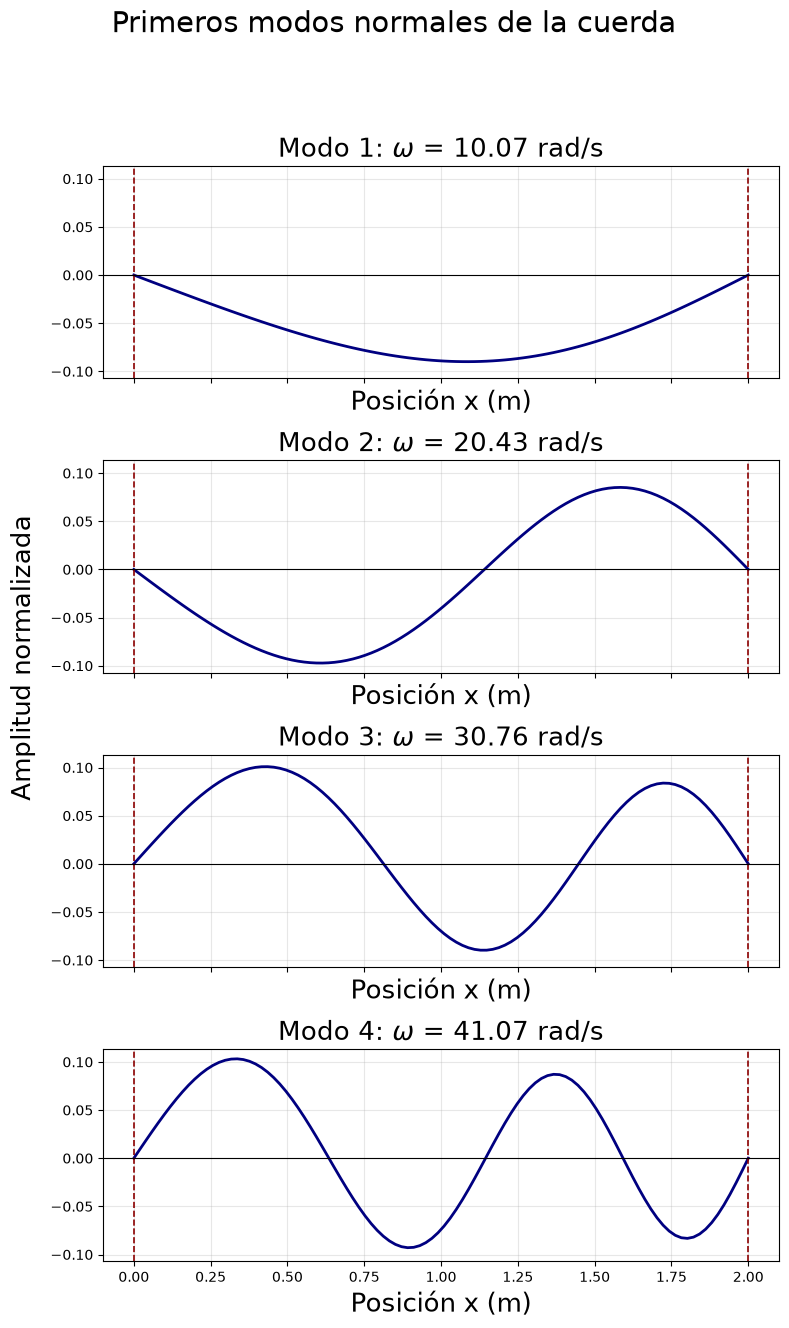

In [59]:
# Visualización de los cuatro primeros modos normales
fig, axes = plt.subplots(
    4, 1, figsize=(8, 13.5), sharex=True, sharey=True
)

for modo, ax in enumerate(axes.flat):
    ax.plot(
        x_malla,
        modos_malla_ord[modo],
        color="navy",
        linewidth=2
    )
    
    ax.axvline(
        0.0,
        color="darkred",
        linestyle="--",
        linewidth=1.2
    )
    
    ax.axvline(
        l,
        color="darkred",
        linestyle="--",
        linewidth=1.2
    )
    
    ax.axhline(
        0.0,
        color="black",
        linewidth=0.8
    )
    
    ax.set_title(
        f"Modo {modo + 1}: $\\omega$ = {omega[modo]:.2f} rad/s",
        fontsize=19
    )
    
    ax.set_xlabel(
        "Posición x (m)",
        fontsize=19
    )
    
    ax.grid(alpha=0.3)

fig.supylabel(
    "Amplitud normalizada",
    fontsize=19
)

fig.suptitle(
    "Primeros modos normales de la cuerda",
    fontsize=21
)

# Espacio horizontal entre las gráficas
fig.subplots_adjust(wspace=0.35)

fig.tight_layout(rect=[0, 0, 1, 0.93])

fig.savefig(
    "modos_normales_cuerda.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Frecuencias propias para distintos valores de alpha (rad/s):


,omega_1,omega_2,omega_3,omega_4
alpha,,,,
0.0,15.707330,31.410861,47.106794,62.791334
0.1,14.973672,29.955449,44.927389,59.887784
0.5,12.794391,25.717786,38.610134,51.485268
1.0,11.047823,22.342869,33.596145,44.826924
1.5,9.858945,20.029897,30.160180,40.266613
2.0,8.984396,18.314612,27.608738,36.879710


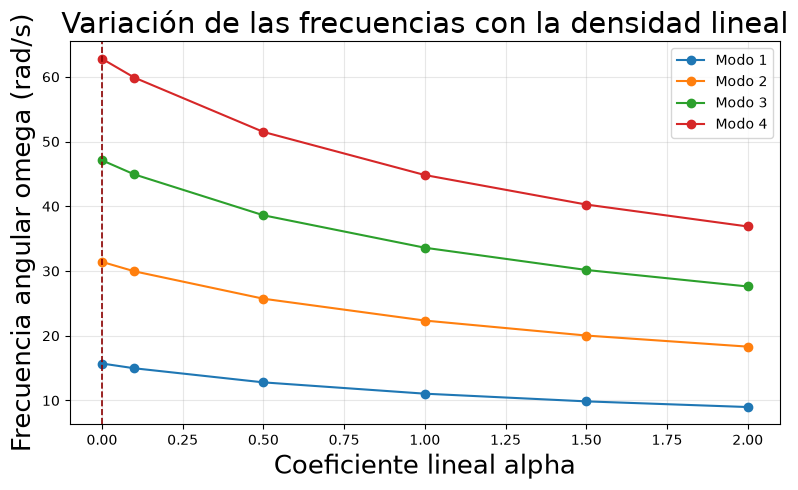

In [62]:
# Estudio paramétrico: mu(x) = mu_0 * (1 + alpha * x)
# alpha = 0.1 corresponde al caso de referencia
mu_0 = 1.0
alpha_valores = np.array([0.0, 0.1, 0.5, 1, 1.5, 2])

frecuencias_alpha = []
modos_alpha = []

for alpha in alpha_valores:
    mu_alpha = lambda x, alpha=alpha: mu_0 * (1.0 + alpha * x)
    A_alpha, M_alpha = EDO(l, f_T, mu_alpha, n)
    C_alpha, D_alpha, _ = simetric(l, f_T, mu_alpha, n)
    eigen_alpha, vectors_alpha = jacobi(
        C_alpha.copy(), tol, n, n_max
    )
    U_alpha, modos_malla_alpha, x_alpha = modos_originales(
        D_alpha, vectors_alpha, mu_alpha, l, n
    )
    omega_alpha, _, _, _ = frequencies(eigen_alpha, U_alpha)

    frecuencias_alpha.append(omega_alpha[:4])
    modos_alpha.append(modos_malla_alpha)

frecuencias_alpha = np.array(frecuencias_alpha)
frecuencias_relativas = frecuencias_alpha / frecuencias_alpha[2]

resultados_alpha = pd.DataFrame(
    frecuencias_alpha,
    index=alpha_valores,
    columns=["omega_1", "omega_2", "omega_3", "omega_4"],
)
resultados_alpha.index.name = "alpha"

print("Frecuencias propias para distintos valores de alpha (rad/s):")
display(resultados_alpha)

fig, ax = plt.subplots(figsize=(8, 5))
for modo in range(4):
    ax.plot(
        alpha_valores,
        frecuencias_alpha[:, modo],
        marker="o",
        label=f"Modo {modo + 1}",
    )
ax.axvline(0.0, color="darkred", linestyle="--", linewidth=1.2)
ax.set_xlabel("Coeficiente lineal alpha", fontsize=19)
ax.set_ylabel("Frecuencia angular omega (rad/s)", fontsize=19)
ax.set_title("Variación de las frecuencias con la densidad lineal", fontsize=21)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.savefig(
    "frecuencias_vs_alpha.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

L = 1.0
n = 3; dx = 0.25
T = 1.0
T/dx^2 = 16.0
N_max = 200


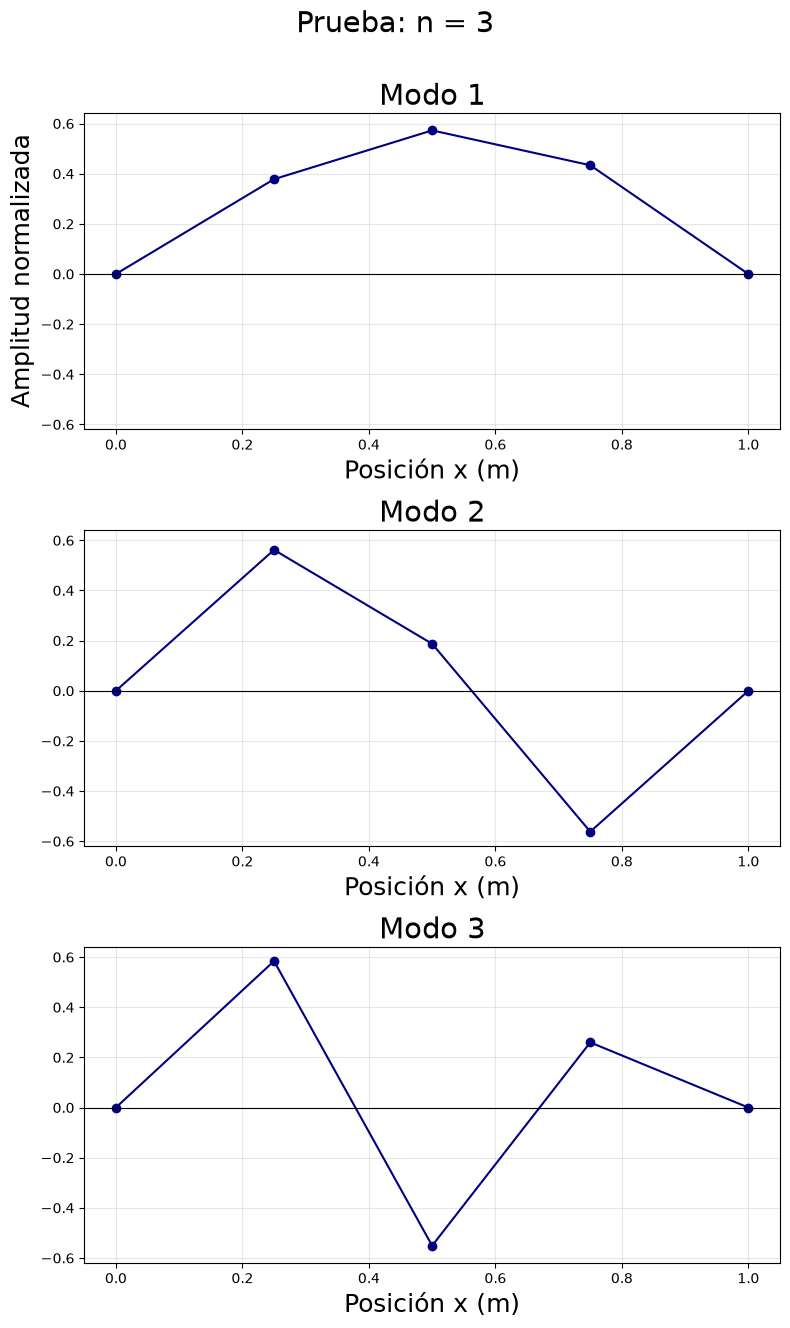

In [38]:
# Prueba con n = 3 y T/dx^2 = 16
L_prueba_variable = 1.0
n_prueba_variable = 3
N_max_prueba_variable = 200
mu_prueba_variable = lambda x: 1.0 + x

# Para n = 3 y L = 1: dx = L/(n+1) = 0.25
# La condición T/dx^2 = 16 determina T = 16*dx^2 = 1.
dx_prueba_variable = L_prueba_variable / (n_prueba_variable + 1)
T_prueba_variable = 16.0 * dx_prueba_variable**2

a_prueba_variable, m_prueba_variable = EDO(
    L_prueba_variable,
    T_prueba_variable,
    mu_prueba_variable,
    n_prueba_variable
)

c_prueba_variable, d_prueba_variable, _ = simetric(
    L_prueba_variable,
    T_prueba_variable,
    mu_prueba_variable,
    n_prueba_variable
)

eigen_prueba_variable, vectores_prueba_variable = jacobi(
    c_prueba_variable.copy(),
    tol,
    n_prueba_variable,
    N_max_prueba_variable
)

u_prueba_variable, modos_malla_prueba_variable, x_malla_prueba_variable = modos_originales(
    d_prueba_variable,
    vectores_prueba_variable,
    mu_prueba_variable,
    L_prueba_variable,
    n_prueba_variable
)

omega_prueba_variable, frecuencia_prueba_variable, modos_ordenados_prueba_variable, eigen_ordenados_prueba_variable = frequencies(
    eigen_prueba_variable,
    u_prueba_variable
)

orden_prueba_variable = np.argsort(eigen_prueba_variable)

modos_malla_ordenados_prueba_variable = [
    modos_malla_prueba_variable[i] for i in orden_prueba_variable
]

print(f"L = {L_prueba_variable}")
print(f"n = {n_prueba_variable}; dx = {dx_prueba_variable}")
print(f"T = {T_prueba_variable}")
print(f"T/dx^2 = {T_prueba_variable / dx_prueba_variable**2}")
print(f"N_max = {N_max_prueba_variable}")

fig_prueba_variable, axes_prueba_variable = plt.subplots(
    n_prueba_variable, 1, figsize=(8, 13.5), sharey=True
)

for modo, ax in enumerate(np.atleast_1d(axes_prueba_variable)):
    ax.plot(
        x_malla_prueba_variable,
        modos_malla_ordenados_prueba_variable[modo],
        marker="o",
        color="navy",
    )

    ax.axhline(0.0, color="black", linewidth=0.8)

    ax.set_title(f"Modo {modo + 1}", fontsize=21)
    ax.set_xlabel("Posición x (m)", fontsize=18)
    ax.grid(alpha=0.3)

axes_prueba_variable[0].set_ylabel("Amplitud normalizada", fontsize=18)

fig_prueba_variable.suptitle("Prueba: n = 3", fontsize=21)

# Espaciado entre las gráficas
fig_prueba_variable.subplots_adjust(hspace=0.45)

fig_prueba_variable.tight_layout(rect=[0, 0, 1, 0.97])

fig_prueba_variable.savefig(
    "modos_prueba_n3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# DataFrame de autovalores lambda y frecuencias angulares
resultados_prueba = pd.DataFrame({
    "modo": np.arange(1, n_prueba + 1),
    "lambda": eigen_ordenados_prueba,
    "frecuencia_angular_rad_s": omega_prueba,
})

print("Autovalores y frecuencias angulares:")
display(resultados_prueba)

Autovalores y frecuencias angulares:


,modo,lambda,frecuencia_angular_rad_s
0,1,9.372583,3.061467
1,2,32.000000,5.656854
2,3,54.627417,7.391036


L = 1.0
n = 3; dx = 0.25
T = 1.0
T/dx^2 = 16.0
N_max = 200


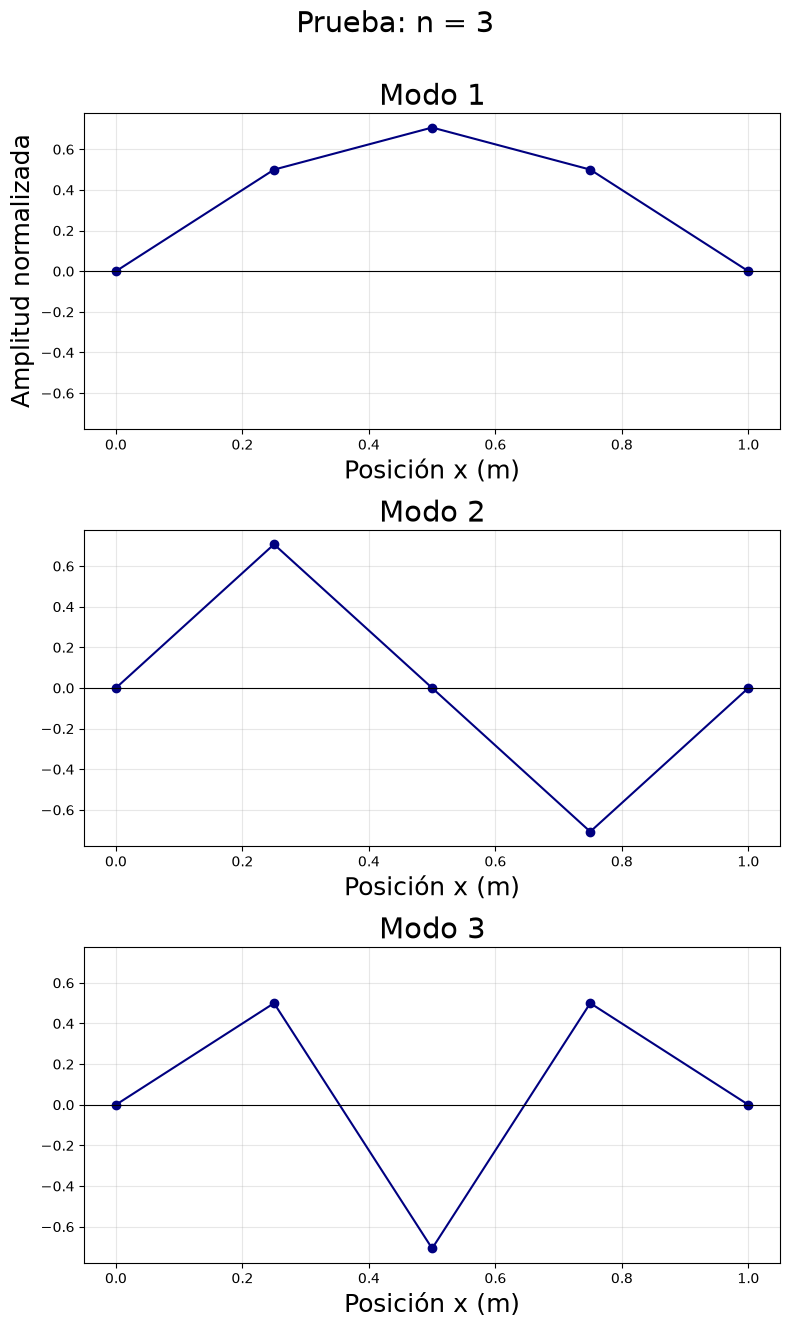

In [40]:
# Prueba con n = 3 y T/dx^2 = 16
L_prueba = 1.0
n_prueba = 3
N_max_prueba = 200
mu_prueba = lambda x: 1.0 

# Para n = 3 y L = 1: dx = L/(n+1) = 0.25
# La condición T/dx^2 = 16 determina T = 16*dx^2 = 1.
dx_prueba = L_prueba / (n_prueba + 1)
T_prueba = 16.0 * dx_prueba**2

a_prueba, m_prueba = EDO(L_prueba, T_prueba, mu_prueba, n_prueba)
c_prueba, d_prueba, _ = simetric(
    L_prueba, T_prueba, mu_prueba, n_prueba
)
eigen_prueba, vectores_prueba = jacobi(
    c_prueba.copy(), tol, n_prueba, N_max_prueba
)
u_prueba, modos_malla_prueba, x_malla_prueba = modos_originales(
    d_prueba, vectores_prueba, mu_prueba, L_prueba, n_prueba
)
omega_prueba, frecuencia_prueba, modos_ordenados_prueba, eigen_ordenados_prueba = frequencies(
    eigen_prueba, u_prueba
)
orden_prueba = np.argsort(eigen_prueba)
modos_malla_ordenados_prueba = [
    modos_malla_prueba[i] for i in orden_prueba
]

print(f"L = {L_prueba}")
print(f"n = {n_prueba}; dx = {dx_prueba}")
print(f"T = {T_prueba}")
print(f"T/dx^2 = {T_prueba / dx_prueba**2}")
print(f"N_max = {N_max_prueba}")

fig_prueba, axes_prueba = plt.subplots(
    n_prueba, 1, figsize=(8, 13.5), sharey=True
)

for modo, ax in enumerate(np.atleast_1d(axes_prueba)):
    ax.plot(
        x_malla_prueba,
        modos_malla_ordenados_prueba[modo],
        marker="o",
        color="navy",
    )

    ax.axhline(0.0, color="black", linewidth=0.8)

    ax.set_title(f"Modo {modo + 1}", fontsize=21)
    ax.set_xlabel("Posición x (m)", fontsize=18)
    ax.grid(alpha=0.3)

axes_prueba[0].set_ylabel("Amplitud normalizada", fontsize=18)

fig_prueba.suptitle("Prueba: n = 3", fontsize=21)

# Espaciado entre las gráficas
fig_prueba.subplots_adjust(hspace=0.45)

fig_prueba.tight_layout(rect=[0, 0, 1, 0.97])

fig_prueba.savefig(
    "modos_prueba_n3_homogenea.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [43]:
diferencia_modos = (np.abs(
    np.array(modos_malla_ordenados_prueba_variable)
    - np.array(modos_malla_ordenados_prueba))
)

In [48]:
diferencia_nodo_final = diferencia_modos[:, -2]
print("Diferencia en el último nodo (cerca de x=L):")
print(diferencia_nodo_final)

Diferencia en el último nodo (cerca de x=L):
[0.06626137 0.14515523 0.24017348]
